Compute L1, L2, and L-infinity distances between (1, 2, 3) and (4, 0, 6). Verify that L-inf <= L2 <= L1 always holds for any pair of points. Prove why this ordering is guaranteed.

In [6]:
import math
def l1_distance(a,b):
    return sum(abs(ai-bi) for ai,bi in zip(a,b))

In [2]:
def l2_distance(a,b):
    return math.sqrt(sum(abs(ai-bi)**2 for ai,bi in zip(a,b)))

In [3]:
def linf_distance(a, b):
    return max(abs(ai - bi) for ai, bi in zip(a, b))

In [8]:
def distance():
    a=[1,2,3]
    b=[4,0,6]
    print(f"A={a}")
    print(f"B={b}")
    print(f"Linf={linf_distance(a,b):.4f}")
    print(f"L1={l1_distance(a,b):.4f}")
    print(f"L2={l2_distance(a,b):.4f}")
    
distance()

A=[1, 2, 3]
B=[4, 0, 6]
Linf=3.0000
L1=8.0000
L2=4.6904


Create two vectors where cosine similarity is high (> 0.9) but L2 distance is large (> 10). Explain geometrically what is happening. Then create two vectors where cosine similarity is low (< 0.3) but L2 distance is small (< 0.5).

Case 1: cos=1.000, L2=15.556
Case 2: cos=0.000, L2=1.077


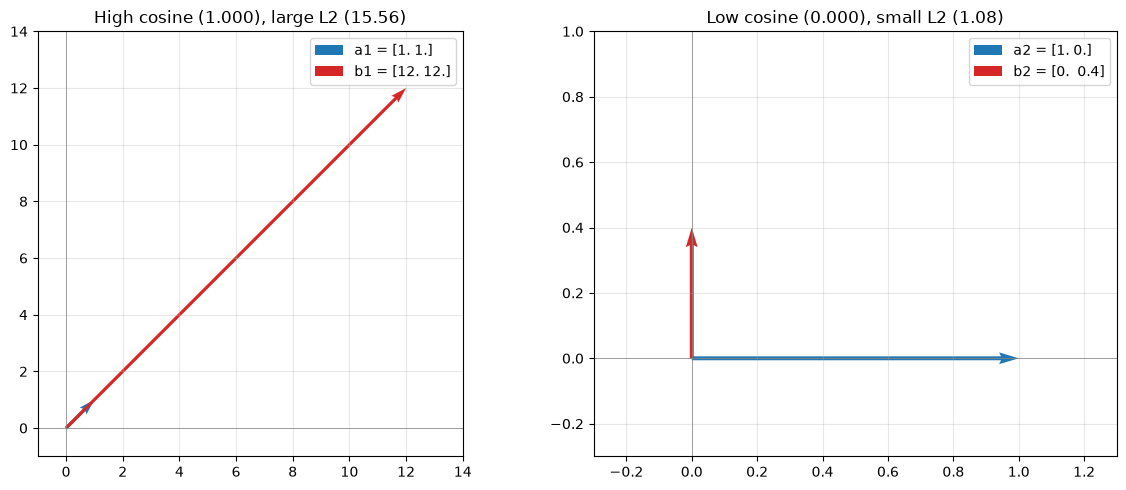

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def l2(a, b):
    return np.linalg.norm(np.array(a) - np.array(b))

# ---------- Case 1: high cosine, large L2 ----------
a1 = np.array([1.0, 1.0])
b1 = np.array([12.0, 12.0])          # same direction, 12x longer

# ---------- Case 2: low cosine, small L2 ----------
a2 = np.array([1.0, 0.0])
b2 = np.array([0.0, 0.4])            # tiny vectors, nearly orthogonal

for name, (a, b) in [("Case 1", (a1, b1)), ("Case 2", (a2, b2))]:
    print(f"{name}: cos={cosine_sim(a,b):.3f}, L2={l2(a,b):.3f}")

# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Case 1
ax = axes[0]
ax.quiver(0, 0, a1[0], a1[1], angles='xy', scale_units='xy', scale=1,
          color='tab:blue', label=f'a1 = {a1}')
ax.quiver(0, 0, b1[0], b1[1], angles='xy', scale_units='xy', scale=1,
          color='tab:red', label=f'b1 = {b1}')
ax.set_xlim(-1, 14); ax.set_ylim(-1, 14)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal')
ax.set_title(f"High cosine ({cosine_sim(a1,b1):.3f}), large L2 ({l2(a1,b1):.2f})")
ax.legend(); ax.grid(alpha=0.3)

# Case 2
ax = axes[1]
ax.quiver(0, 0, a2[0], a2[1], angles='xy', scale_units='xy', scale=1,
          color='tab:blue', label=f'a2 = {a2}')
ax.quiver(0, 0, b2[0], b2[1], angles='xy', scale_units='xy', scale=1,
          color='tab:red', label=f'b2 = {b2}')
ax.set_xlim(-0.3, 1.3); ax.set_ylim(-0.3, 1.0)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal')
ax.set_title(f"Low cosine ({cosine_sim(a2,b2):.3f}), small L2 ({l2(a2,b2):.2f})")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Implement MinHash for approximate Jaccard similarity. Generate 100 random sets, compute exact Jaccard for all pairs, and compare with MinHash approximation using 50, 100, and 200 hash functions. Plot the approximation error

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

rng = np.random.default_rng(42)

# ---------- 1. Generate 100 random sets over a universe of 500 elements ----------
N_SETS = 100
UNIVERSE = 500
SET_SIZE_RANGE = (30, 120)

sets = []
for _ in range(N_SETS):
    size = rng.integers(*SET_SIZE_RANGE)
    s = set(rng.choice(UNIVERSE, size=size, replace=False).tolist())
    sets.append(s)

# ---------- 2. Exact Jaccard ----------
def jaccard(A, B):
    inter = len(A & B)
    union = len(A | B)
    return inter / union if union else 0.0

pairs = list(combinations(range(N_SETS), 2))
exact = np.array([jaccard(sets[i], sets[j]) for i, j in pairs])

# ---------- 3. MinHash ----------
def minhash_signatures(sets, k, rng):
    """
    Returns an (n_sets, k) matrix of MinHash signatures.
    Uses the standard (a*x + b) mod p universal hash family,
    which mimics random permutations well enough for Jaccard estimation.
    """
    # Large prime > universe size
    p = 2_147_483_647  # Mersenne prime 2^31 - 1

    # Random hash coefficients
    a = rng.integers(1, p, size=k)
    b = rng.integers(0, p, size=k)

    n = len(sets)
    sig = np.full((n, k), np.iinfo(np.int64).max, dtype=np.int64)

    for i, s in enumerate(sets):
        if not s:
            continue
        # Convert set to array once
        elems = np.fromiter(s, dtype=np.int64, count=len(s))
        # For each hash function, compute min over elements
        # Vectorized: (k, |s|) then min over axis 1
        hashes = (a[:, None] * elems[None, :] + b[:, None]) % p
        sig[i] = hashes.min(axis=1)

    return sig

def minhash_jaccard(sig):
    """
    Estimate pairwise Jaccard from a (n_sets, k) signature matrix.
    Returns the upper-triangle vector in the same order as `pairs`.
    """
    n, k = sig.shape
    est = np.empty(len(pairs))
    for idx, (i, j) in enumerate(pairs):
        est[idx] = np.mean(sig[i] == sig[j])
    return est

# ---------- 4. Run for k = 50, 100, 200 ----------
ks = [50, 100, 200]
results = {}
for k in ks:
    sig = minhash_signatures(sets, k, rng)
    est = minhash_jaccard(sig)
    err = np.abs(est - exact)
    results[k] = {"est": est, "err": err}
    print(f"k={k:4d} | MAE={err.mean():.4f} | RMSE={np.sqrt((err**2).mean()):.4f} "
          f"| max_err={err.max():.4f} | corr={np.corrcoef(est, exact)[0,1]:.4f}")

k=  50 | MAE=0.0288 | RMSE=0.0365 | max_err=0.1666 | corr=0.6336
k= 100 | MAE=0.0206 | RMSE=0.0263 | max_err=0.1071 | corr=0.7544
k= 200 | MAE=0.0146 | RMSE=0.0187 | max_err=0.0800 | corr=0.8512


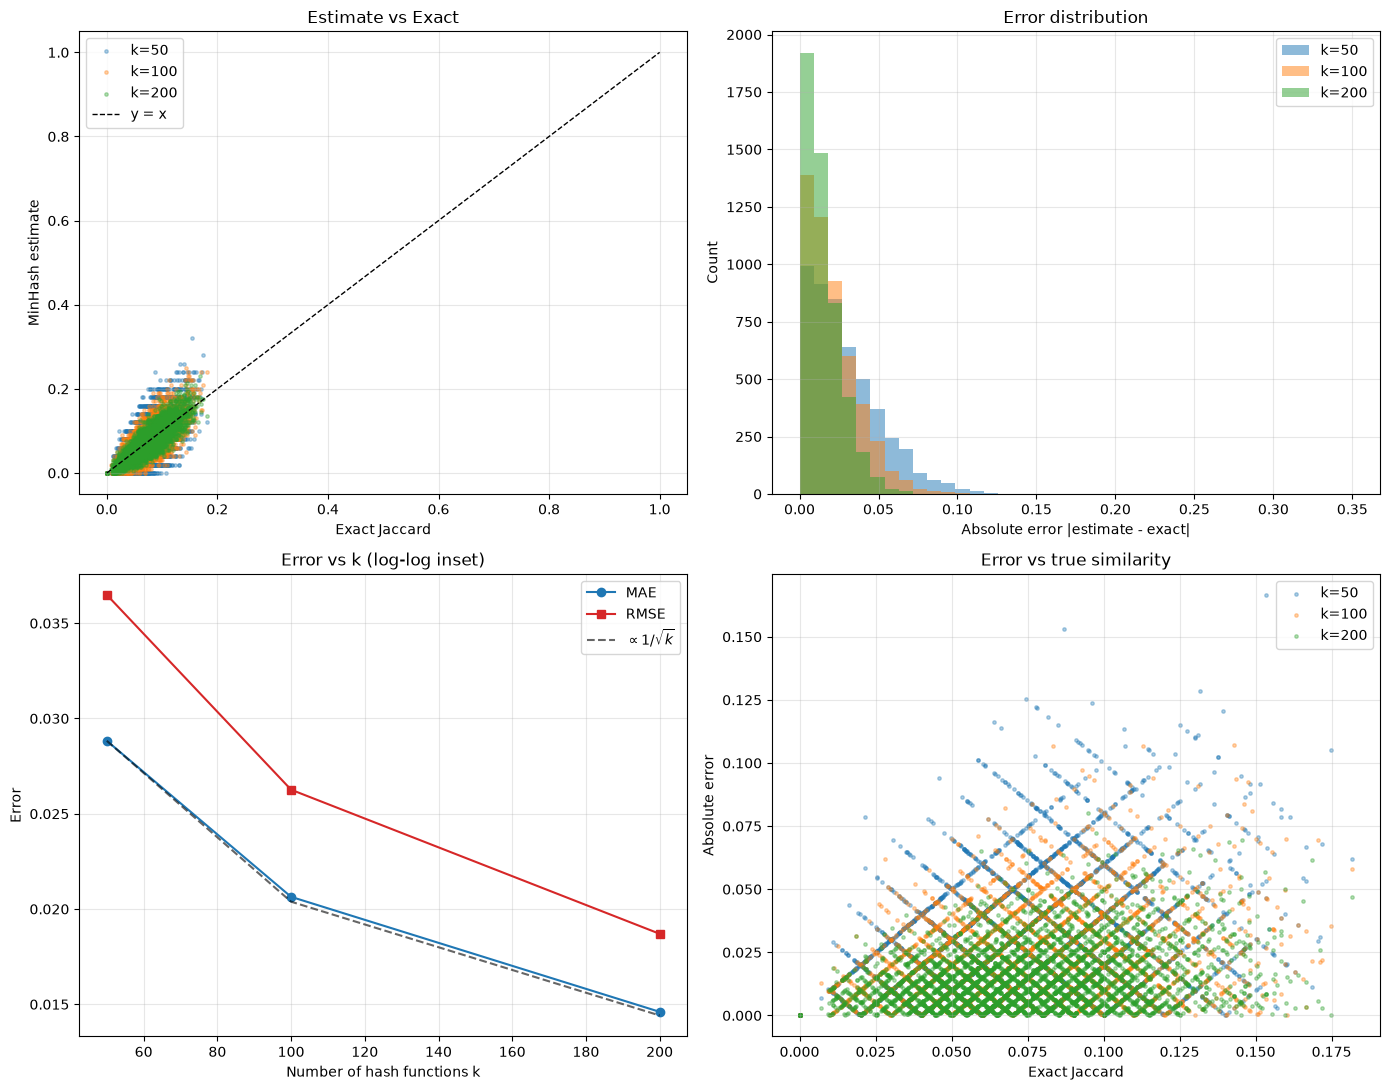

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# ---- Panel A: MinHash estimate vs exact ----
ax = axes[0, 0]
colors = {50: "tab:blue", 100: "tab:orange", 200: "tab:green"}
for k in ks:
    est = results[k]["est"]
    ax.scatter(exact, est, s=6, alpha=0.35, label=f"k={k}",
               color=colors[k])
ax.plot([0, 1], [0, 1], "k--", lw=1, label="y = x")
ax.set_xlabel("Exact Jaccard")
ax.set_ylabel("MinHash estimate")
ax.set_title("Estimate vs Exact")
ax.legend()
ax.grid(alpha=0.3)

# ---- Panel B: Error distribution ----
ax = axes[0, 1]
bins = np.linspace(0, 0.35, 40)
for k in ks:
    ax.hist(results[k]["err"], bins=bins, alpha=0.5,
            label=f"k={k}", color=colors[k])
ax.set_xlabel("Absolute error |estimate - exact|")
ax.set_ylabel("Count")
ax.set_title("Error distribution")
ax.legend()
ax.grid(alpha=0.3)

# ---- Panel C: MAE / RMSE vs k ----
ax = axes[1, 0]
maes = [results[k]["err"].mean() for k in ks]
rmses = [np.sqrt((results[k]["err"]**2).mean()) for k in ks]
ax.plot(ks, maes, "o-", label="MAE", color="tab:blue")
ax.plot(ks, rmses, "s-", label="RMSE", color="tab:red")

# Theoretical 1/sqrt(k) guide
ref = maes[0] * np.sqrt(50 / np.array(ks))
ax.plot(ks, ref, "k--", alpha=0.6, label=r"$\propto 1/\sqrt{k}$")

ax.set_xlabel("Number of hash functions k")
ax.set_ylabel("Error")
ax.set_title("Error vs k (log-log inset)")
ax.legend()
ax.grid(alpha=0.3, which="both")

# ---- Panel D: Error vs exact Jaccard (bias check) ----
ax = axes[1, 1]
for k in ks:
    ax.scatter(exact, results[k]["err"], s=6, alpha=0.35,
               color=colors[k], label=f"k={k}")
ax.set_xlabel("Exact Jaccard")
ax.set_ylabel("Absolute error")
ax.set_title("Error vs true similarity")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("minhash_error.png", dpi=120)
plt.show()